<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/read_wav_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Created by EDES**


mainly helped by claude-ai

Downloaded to local_wav_0.wav
Downloaded to local_wav_1.wav
Downloaded to local_wav_2.wav
Downloaded to local_wav_3.wav
Downloaded to local_wav_4.wav
Downloaded to local_wav_5.wav
data-0 length:165375 - rate:44100Hz - max_val:0.20678962767124176 @ 77143
data-1 length:165375 - rate:44100Hz - max_val:0.22090013325214386 @ 77140
data-2 length:165375 - rate:44100Hz - max_val:0.18920716643333435 @ 77175
data-3 length:165375 - rate:44100Hz - max_val:0.18075722455978394 @ 77141
data-4 length:165375 - rate:44100Hz - max_val:0.17937374114990234 @ 77138
data-5 length:165375 - rate:44100Hz - max_val:0.12392235547304153 @ 77141


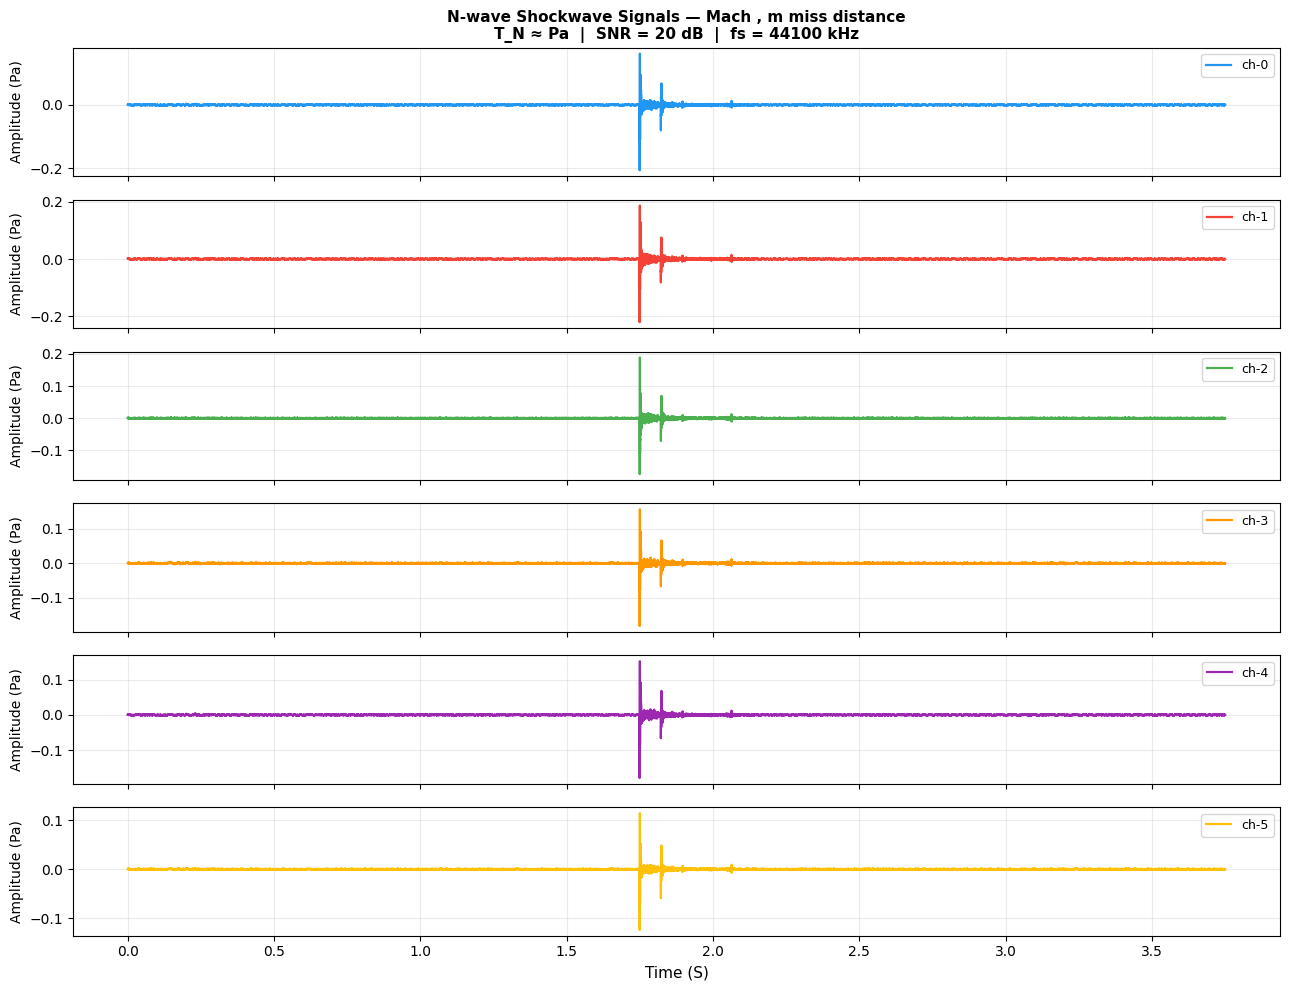

In [89]:
import requests
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import os

wav_file_url=[]
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch0.wav')
#wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch1.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch2.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch3.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch4.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch5.wav')
#wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch6.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_mean.wav')

num_files = len(wav_file_url)

local_file = []
for i in range(num_files):
  local_file.append(f'local_wav_{i}.wav')

# Check if the URL is provided
for i in range(num_files):
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url[i]}...")
        response = requests.get(wav_file_url[i])
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_file[i], 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_file[i]}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_file[i]}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

dataset_signal=[]; max_amplitude_val=[]; max_amplitude_idx=[]
for i in range(num_files):
  dataset_samplerate, dataset = wavfile.read(local_file[i])
  if dataset.ndim > 1:
    dataset = dataset[:, 0] # Take the first channel
  dataset_signal.append(dataset)
  max_amp_idx = np.argmax(np.abs(dataset))
  max_amp_val = np.max(np.abs(dataset))
  max_amplitude_idx.append(max_amp_idx)
  max_amplitude_val.append(max_amp_val)
  print(f"data-{i} length:{len(dataset)} - rate:{dataset_samplerate}Hz - max_val:{max_amp_val} @ {max_amp_idx}")

# Create a time array for the x-axis for the (possibly cropped) data
dataset_time = np.linspace(0., len(dataset) / dataset_samplerate, len(dataset))

COLORS  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#FFC107', '#00BCD4', '#8BC34A']

fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(dataset_time, dataset_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — Mach , '
    f'm miss distance\n'
    f'T_N ≈ Pa  |  '
    f'SNR = 20 dB  |  fs = {dataset_samplerate} kHz',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

starting index for cropping:77015


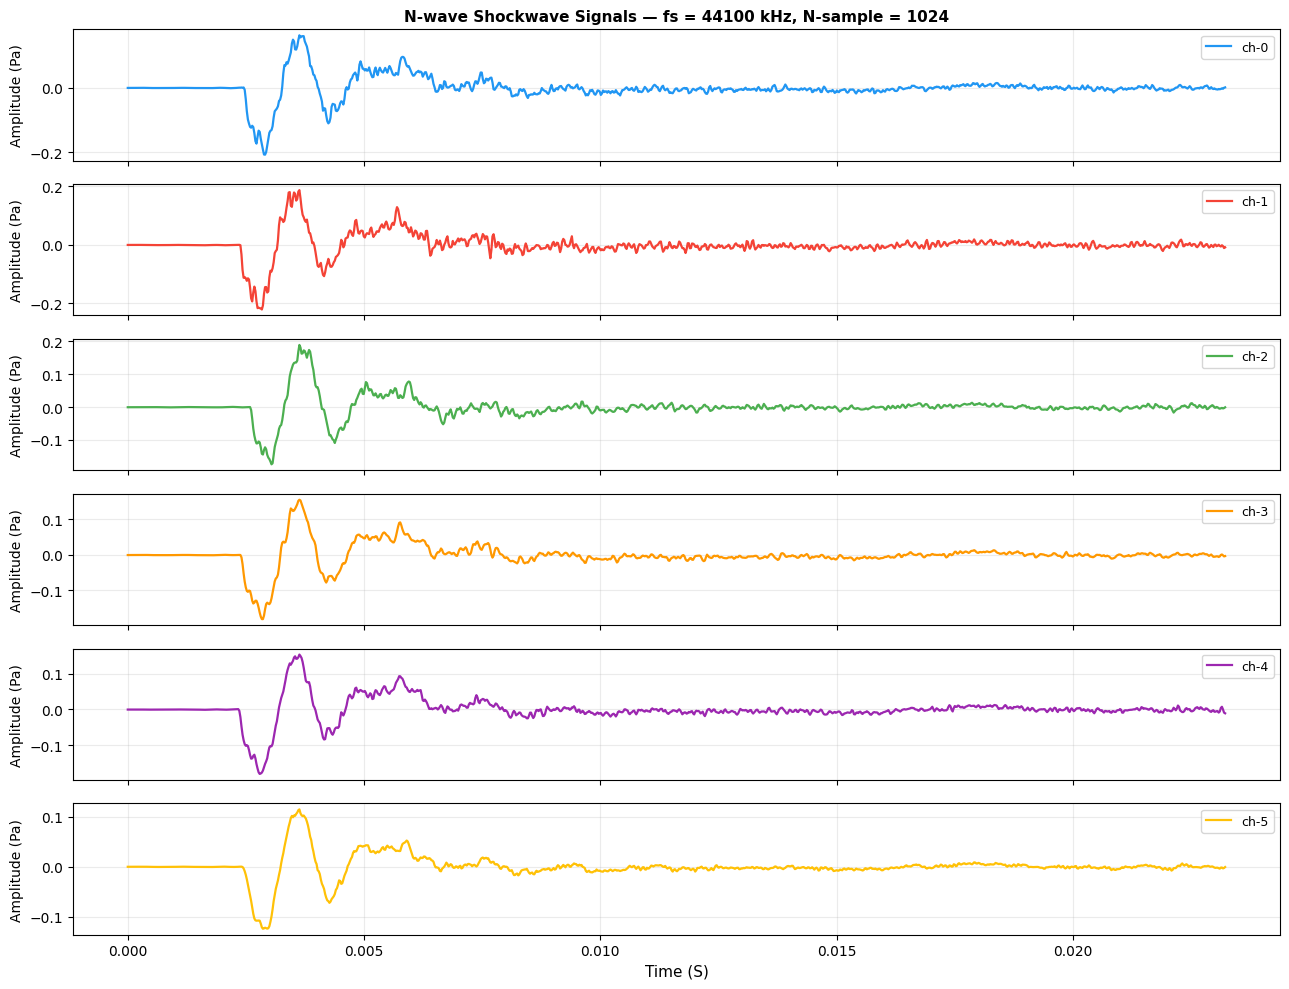

In [90]:
sw_length = 2**10 # 16384 samples
sw_offset = max(0, int(max_amplitude_idx[0] - 128))
print(f"starting index for cropping:{smallest_offset}")

end_sw_idx = sw_offset + sw_length

data_sw_signal=[]
for i in range(num_files):
  sw_signal = dataset_signal[i][sw_offset:end_sw_idx]
  data_sw_signal.append(sw_signal)

data_sw_time = np.linspace(0., sw_length / dataset_samplerate, sw_length)

fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(data_sw_time, data_sw_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — fs = {dataset_samplerate} kHz, N-sample = {target_length}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

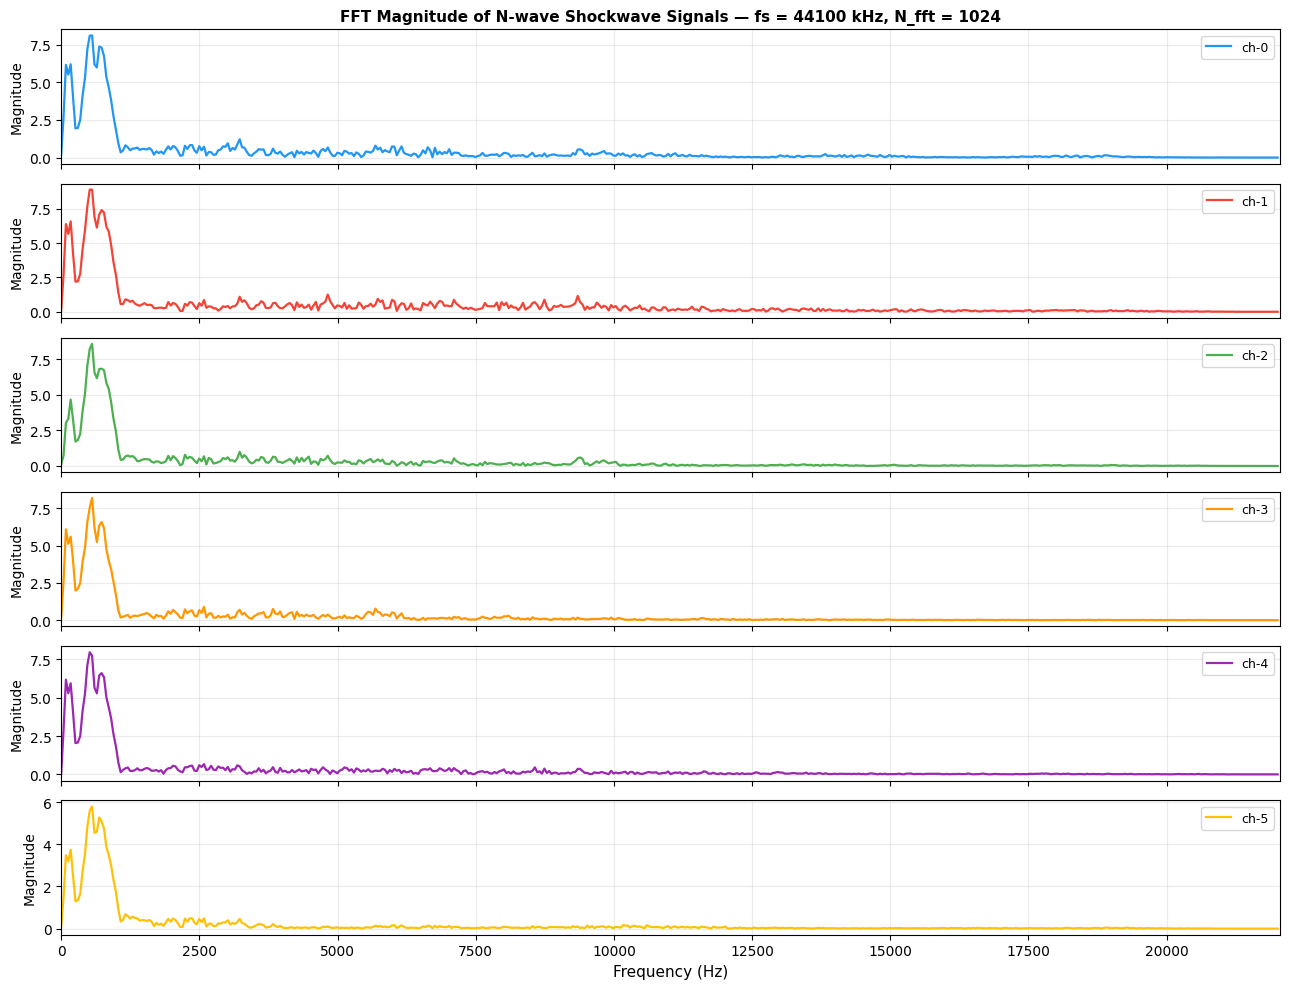

In [91]:
from scipy.fft import fft, fftfreq

# N_fft is already defined as 1024. For this FFT calculation, we will use N_fft.
# This means the FFT will be computed over 1024 samples. If the signal is longer
# than N_fft, it will effectively truncate or consider the first N_fft samples
# of the provided signal for the FFT, or it implies zero-padding if the signal is shorter.

N_fft = 1024 # Use the N_fft variable as the FFT length

# Calculate FFT and frequencies for each signal
freqs = fftfreq(N_fft, 1 / dataset_samplerate)

fig, axes_fft = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    # Compute FFT for the current signal using N_fft_actual points
    # If the signal length is greater than N_fft_actual, it will be truncated.
    yf = fft(data_sw_signal[i], n=N_fft)
    # Take the magnitude and normalize, and consider only the positive frequencies
    magnitude = np.abs(yf[:N_fft // 2])

    ax = axes_fft[i]
    ax.plot(freqs[:N_fft // 2], magnitude, color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Magnitude', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_xlim([0, dataset_samplerate / 2]) # Limit x-axis to Nyquist frequency

axes_fft[-1].set_xlabel('Frequency (Hz)', fontsize=11)
axes_fft[0].set_title(
    f'FFT Magnitude of N-wave Shockwave Signals — fs = {dataset_samplerate} kHz, N_fft = {N_fft}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

GCC-PHAT of Shockwave (x16 zero-padding -> 1.417 us resolution)
----------------------------------------------------------------
Pair      True tau (us)   Est tau (us)    Error (us)
  (0,1)           -94.955   
  (0,2)          +143.141   
  (0,3)           -62.358   
  (0,4)           -90.703   
  (0,5)          +151.644   


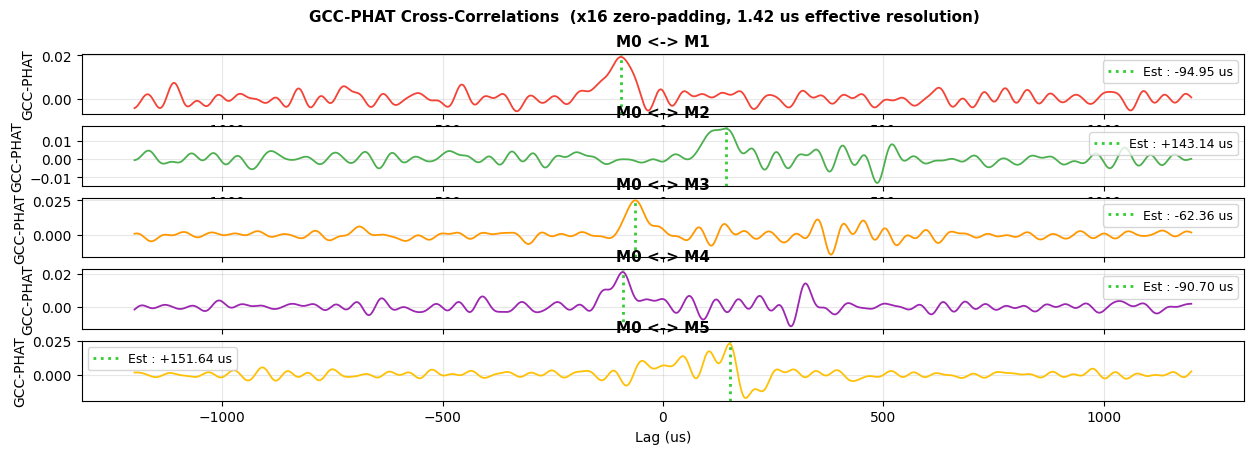

In [92]:
# ╔══════════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 8.1 — GCC-PHAT Algorithm & Shockwave TDOA                              ║
# ╚══════════════════════════════════════════════════════════════════════════════════╝
#  Algorithm
#  ---------
#  1. FFT both signals with n = N (native resolution, no time-domain zero-pad).
#  2. PHAT-weighted cross-spectrum:  G(f) = X1(f).X2*(f) / |X1(f).X2*(f)|
#  3. TDOA = argmax_tau { IFFT(G, zero-padded to n*interp_factor)[tau] }
#     (zero-padding in the FREQUENCY domain before the inverse FFT is what
#     gives sub-sample TDOA resolution -- doing it in the time domain before
#     the forward FFT instead causes a lag-scaling bug.)
#
#  At fs = 100 kHz, x16 zero-padding -> effective resolution = 0.625 us.
#
#  Reference: Knapp & Carter (1976), "The generalised cross-correlation
#             method for estimation of time delay", IEEE Trans. ASSP.
C     = 343.0      # Speed of sound (m/s) -- ISA sea level
L_ARRAY = 0.30

def gcc_phat(x1, x2, fs, interp_factor=16, max_lag_s=None):
    n = len(x1)
    X1 = np.fft.rfft(x1, n=n)
    X2 = np.fft.rfft(x2, n=n)
    G  = X2 * np.conj(X1)              # x2 relative to x1 (positive tau = x2 arrives later)
    G /= (np.abs(G) + 1e-12)
    nf = n * interp_factor
    cc = np.fft.fftshift(np.fft.irfft(G, n=nf))   # interpolation happens HERE
    lags = np.arange(-nf//2, nf//2) / (fs * interp_factor)
    if max_lag_s is None:
        max_lag_s = 1.5 * L_ARRAY / C
    mask = np.abs(lags) <= max_lag_s
    idx  = np.argmax(cc[mask])
    return lags[mask][idx], cc, lags

FS = dataset_samplerate
INTERP = 16
dt_eff = 1e6 / (FS * INTERP)

print(f"GCC-PHAT of Shockwave (x{INTERP} zero-padding -> {dt_eff:.3f} us resolution)")
print("-" * 64)
print(f"{'Pair':<8} {'True tau (us)':>14} {'Est tau (us)':>14} {'Error (us)':>13}")

tdoa_sw_results = {}
for i in range(1, num_files):
    tau_est, cc, lags = gcc_phat(data_sw_signal[0], data_sw_signal[i], FS, interp_factor=INTERP)
    tdoa_sw_results[i]   = (tau_est, cc, lags)
    print(f"  (0,{i})    {tau_est*1e6:>+14.3f}   ")

fig, axes_g = plt.subplots(num_files-1, 1, figsize=(15, 4.5))
WIN_GCC = 1.2e-3

for idx, i in enumerate(range(1, num_files)):
    tau_est, cc, lags = tdoa_sw_results[i]
    ax = axes_g[idx]
    view = np.abs(lags) <= WIN_GCC
    ax.plot(lags[view]*1e6, cc[view], color=COLORS[i], lw=1.3)
    ax.axvline(tau_est*1e6,  color='limegreen', ls=':',  lw=2.0,
               label=f'Est : {tau_est*1e6:+.2f} us')
    ax.set_xlabel('Lag (us)', fontsize=10)
    ax.set_ylabel('GCC-PHAT', fontsize=10)
    ax.set_title(f'M0 <-> M{i}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

fig.suptitle(
    f'GCC-PHAT Cross-Correlations  '
    f'(x{INTERP} zero-padding, {dt_eff:.2f} us effective resolution)',
    fontsize=11, fontweight='bold')
#plt.tight_layout()
plt.savefig('gcc_phat.png', dpi=150, bbox_inches='tight')
plt.show()

starting index for cropping MB :80275


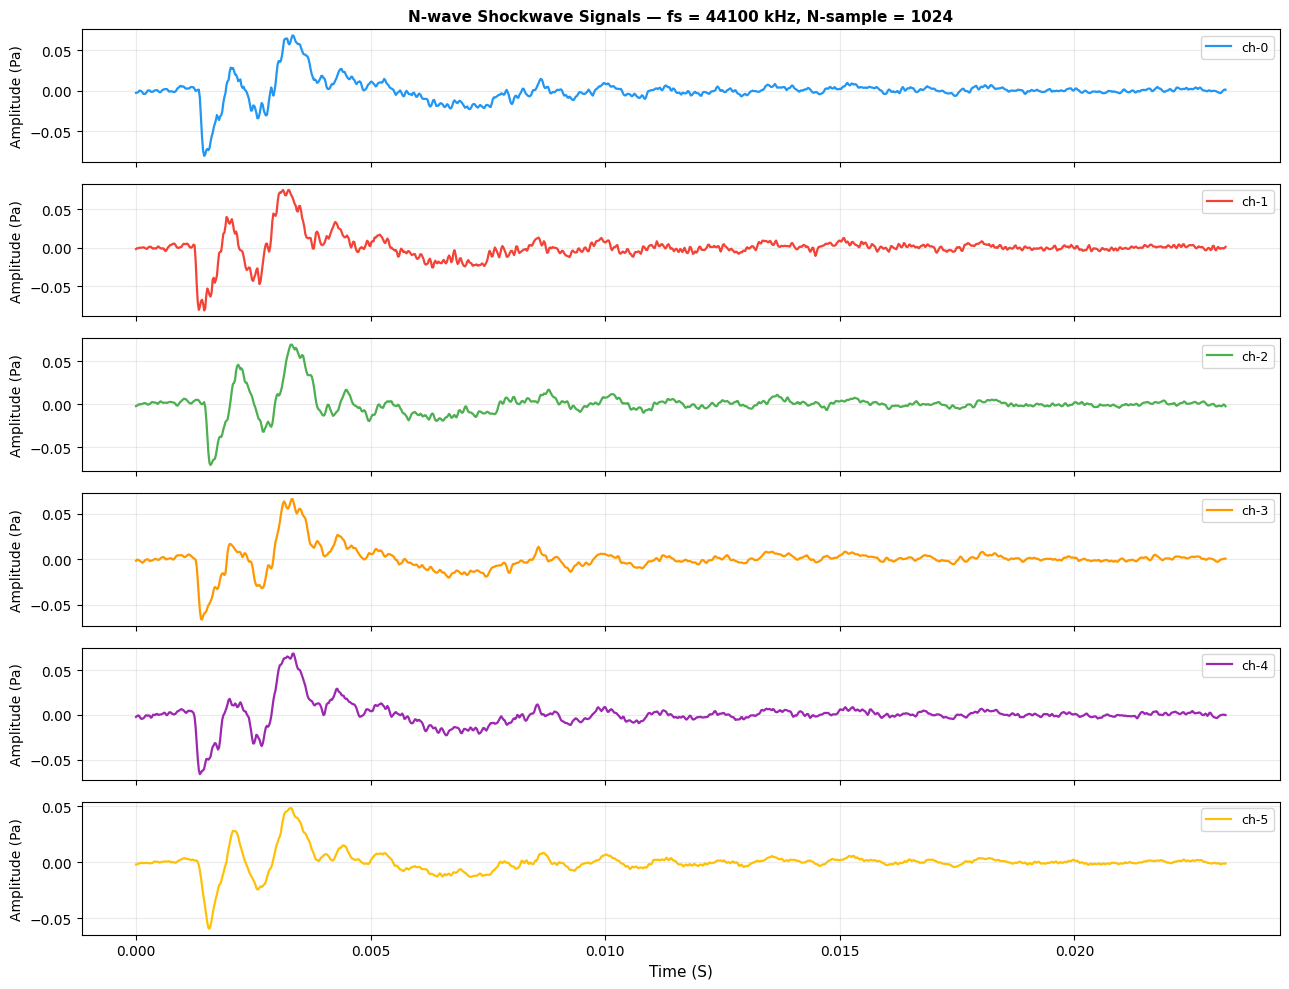

In [93]:
mb_length = 2**10 # 16384 samples

remaining_signal = dataset_signal[0][end_sw_idx:]
mb_offset_idx = np.argmax(np.abs(remaining_signal))

mb_offset = max(0, int(mb_offset_idx - 64)) + end_sw_idx
print(f"starting index for cropping MB :{mb_offset}")

data_mb_signal=[]
for i in range(num_files):
  end_idx = mb_offset + mb_length
  sw_signal = dataset_signal[i][mb_offset:end_idx]
  data_mb_signal.append(sw_signal)

data_mb_time = np.linspace(0., mb_length / dataset_samplerate, mb_length)

fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(data_mb_time, data_mb_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — fs = {dataset_samplerate} kHz, N-sample = {target_length}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

GCC-PHAT of Muzzle-Blast (x16 zero-padding -> 1.417 us resolution)
----------------------------------------------------------------
Pair      True tau (us)   Est tau (us)    Error (us)
  (0,1)           -90.703   
  (0,2)          +126.134   
  (0,3)           -53.855   
  (0,4)           -96.372   
  (0,5)          +147.392   


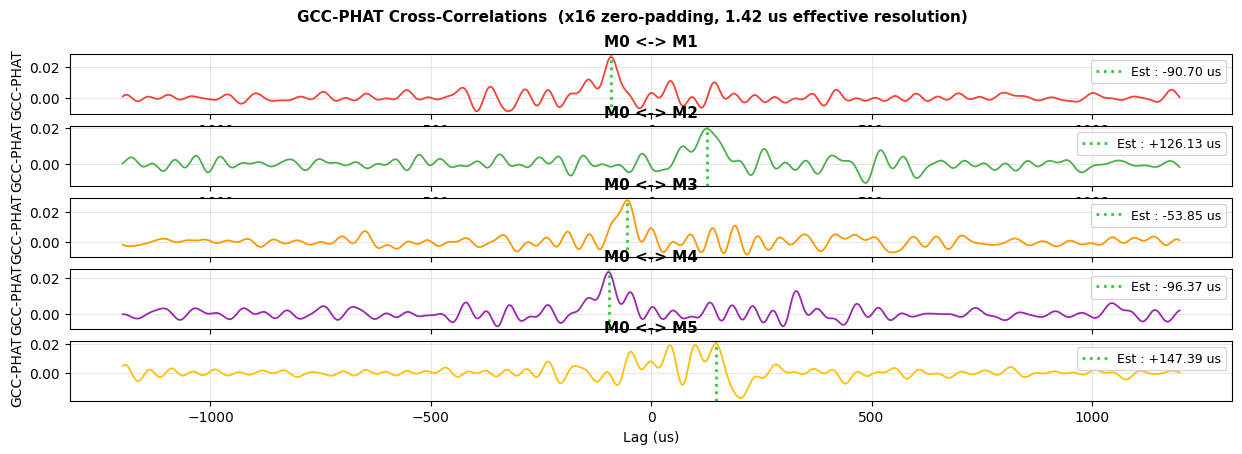

In [94]:
print(f"GCC-PHAT of Muzzle-Blast (x{INTERP} zero-padding -> {dt_eff:.3f} us resolution)")
print("-" * 64)
print(f"{'Pair':<8} {'True tau (us)':>14} {'Est tau (us)':>14} {'Error (us)':>13}")

tdoa_mb_results = {}
for i in range(1, num_files):
    tau_est, cc, lags = gcc_phat(data_mb_signal[0], data_mb_signal[i], FS, interp_factor=INTERP)
    tdoa_mb_results[i]   = (tau_est, cc, lags)
    print(f"  (0,{i})    {tau_est*1e6:>+14.3f}   ")

fig, axes_g = plt.subplots(num_files-1, 1, figsize=(15, 4.5))
WIN_GCC = 1.2e-3

for idx, i in enumerate(range(1, num_files)):
    tau_est, cc, lags = tdoa_mb_results[i]
    ax = axes_g[idx]
    view = np.abs(lags) <= WIN_GCC
    ax.plot(lags[view]*1e6, cc[view], color=COLORS[i], lw=1.3)
    ax.axvline(tau_est*1e6,  color='limegreen', ls=':',  lw=2.0,
               label=f'Est : {tau_est*1e6:+.2f} us')
    ax.set_xlabel('Lag (us)', fontsize=10)
    ax.set_ylabel('GCC-PHAT', fontsize=10)
    ax.set_title(f'M0 <-> M{i}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

fig.suptitle(
    f'GCC-PHAT Cross-Correlations  '
    f'(x{INTERP} zero-padding, {dt_eff:.2f} us effective resolution)',
    fontsize=11, fontweight='bold')
#plt.tight_layout()
plt.savefig('gcc_phat.png', dpi=150, bbox_inches='tight')
plt.show()

Channel 0:
  First Peak: Index = 92, Amplitude = 0.0026
  Second Peak: Index = 149, Amplitude = 0.0018
Channel 1:
  First Peak: Index = 85, Amplitude = 0.0028
  Second Peak: Index = 146, Amplitude = 0.0024
Channel 2:
  First Peak: Index = 41, Amplitude = 0.0015
  Second Peak: Index = 103, Amplitude = 0.0017
Channel 3:
  First Peak: Index = 95, Amplitude = 0.0026
  Second Peak: Index = 152, Amplitude = 0.0021
Channel 4:
  First Peak: Index = 91, Amplitude = 0.0024
  Second Peak: Index = 144, Amplitude = 0.0016
Channel 5:
  First Peak: Index = 94, Amplitude = 0.0015
  Second Peak: Index = 152, Amplitude = 0.0012


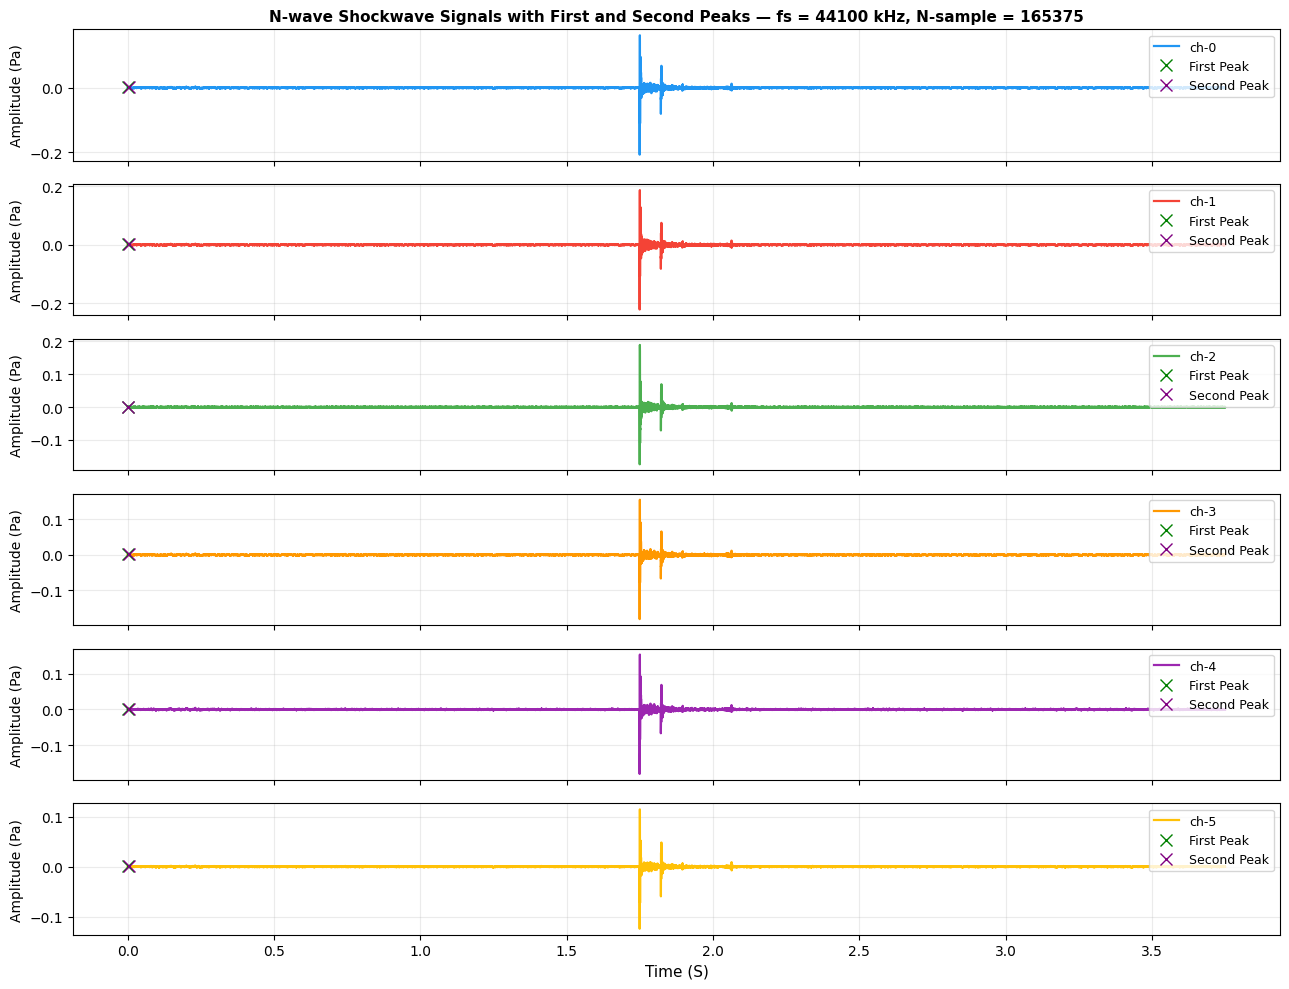

In [95]:
from scipy.signal import find_peaks

all_first_peaks = []
all_second_peaks = []

for i in range(num_files):
    signal_data = dataset_signal[i]

    # Find peaks. Adjust parameters like 'distance', 'prominence', 'width' if needed
    # 'prominence' is a good parameter to filter out small fluctuations and find significant peaks.
    peaks, properties = find_peaks(np.abs(signal_data), prominence=0.0005, distance=50) # Example parameters

    if len(peaks) > 0:
        first_peak_idx = peaks[0]
        all_first_peaks.append((first_peak_idx, signal_data[first_peak_idx]))
    else:
        all_first_peaks.append(None)

    if len(peaks) > 1:
        second_peak_idx = peaks[1]
        all_second_peaks.append((second_peak_idx, signal_data[second_peak_idx]))
    else:
        all_second_peaks.append(None)

    print(f"Channel {i}:")
    if all_first_peaks[i]:
        print(f"  First Peak: Index = {all_first_peaks[i][0]}, Amplitude = {all_first_peaks[i][1]:.4f}")
    else:
        print("  No first peak found.")

    if all_second_peaks[i]:
        print(f"  Second Peak: Index = {all_second_peaks[i][0]}, Amplitude = {all_second_peaks[i][1]:.4f}")
    else:
        print("  No second peak found.")


# Optionally, you can visualize these peaks
fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(dataset_time, dataset_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')

    if all_first_peaks[i]:
        first_peak_idx, first_peak_amp = all_first_peaks[i]
        ax.plot(dataset_time[first_peak_idx], first_peak_amp, 'x', color='green', markersize=8, label='First Peak')

    if all_second_peaks[i]:
        second_peak_idx, second_peak_amp = all_second_peaks[i]
        ax.plot(dataset_time[second_peak_idx], second_peak_amp, 'x', color='purple', markersize=8, label='Second Peak')

    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals with First and Second Peaks — fs = {dataset_samplerate} kHz, N-sample = {len(dataset_signal[0])}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [96]:
max_amplitude_idx_after_sw = []
for i in range(num_files):
  # Get the portion of the signal after the sw_length segment
  remaining_signal = dataset_signal[i][end_sw_idx:]
  if len(remaining_signal) > 0:
    # Find the index of the maximum amplitude in the remaining signal
    max_amp_idx_relative = np.argmax(np.abs(remaining_signal))
    # Convert it back to the absolute index in the original dataset_signal
    max_amp_idx_absolute = end_sw_idx + max_amp_idx_relative
    max_amplitude_idx_after_sw.append(max_amp_idx_absolute)
  else:
    max_amplitude_idx_after_sw.append(None) # No remaining signal

for i, idx in enumerate(max_amplitude_idx_after_sw):
  print(f"Max amplitude index after sw_length for channel {i}: {idx}")

Max amplitude index after sw_length for channel 0: 80339
Max amplitude index after sw_length for channel 1: 80339
Max amplitude index after sw_length for channel 2: 80345
Max amplitude index after sw_length for channel 3: 80337
Max amplitude index after sw_length for channel 4: 80423
Max amplitude index after sw_length for channel 5: 80344
